<a href="https://colab.research.google.com/github/MaheeGamage/TIES4911-DL-for-dev/blob/main/Task-1/Task1-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task 1-2

In [39]:
import pandas as pd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [24]:
"%matplotlib inline"

'%matplotlib inline'

In [25]:
# Linear Regressino implementation

class SimpleLinearRegression:
    def __init__(self, initializer='random'):
        if initializer=='ones':
            self.var = 1.
        elif initializer=='zeros':
            self.var = 0.
        elif initializer=='random':
            self.var = tf.random.uniform(shape=[], minval=0., maxval=1.)
        self.m = tf.Variable(1., shape=tf.TensorShape(None))
        self.b = tf.Variable(self.var)

    def predict(self, x):
        return tf.reduce_sum(self.m * x, 1) + self.b

    def mse(self, true, predicted):
        return tf.reduce_mean(tf.square(true-predicted))

    def update(self, X, y, learning_rate):
        with tf.GradientTape(persistent=True) as g:
            loss = self.mse(y, self.predict(X))
            print("Loss: ", loss)
            dy_dm = g.gradient(loss, self.m)
            dy_db = g.gradient(loss, self.b)
        self.m.assign_sub(learning_rate * dy_dm)
        self.b.assign_sub(learning_rate * dy_db)

    def train(self, X, y, learning_rate=0.01, epochs=5):
        if len(X.shape)==1:
            X=tf.reshape(X,[X.shape[0],1])
        self.m.assign([self.var]*X.shape[-1])
        for i in range(epochs):
            print("Epoch: ", i)
            self.update(X, y, learning_rate)

## Analyzing the dataset

In [26]:
# dataset
df = pd.read_csv("hf://datasets/scikit-learn/auto-mpg/auto-mpg.csv")
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [27]:
# Get the number of unique car names
num_unique_cars = df['car name'].nunique()

print(f"There are {num_unique_cars} unique car names in the dataset.")

There are 305 unique car names in the dataset.


# Preprocessing

In [28]:
# Convert 'horsepower' column to numeric, coercing errors to NaN
df['horsepower'] = pd.to_numeric(df['horsepower'], errors='coerce')

# Fill NaN values with the mean of the column
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].mean())

# Now convert the 'horsepower' column to integers
df['horsepower'] = df['horsepower'].astype(int)

dataset = df.values

In [29]:
dataset = df.values
X = dataset[:,1:8]
X = X.astype(float)
Y = dataset[:,0]
Y = Y.astype(float)

# split the data
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2,
random_state = 0)

# standardize the data
mean_label = y_train.mean(axis=0)
std_label = y_train.std(axis=0)
mean_feat = x_train.mean(axis=0)
std_feat = x_train.std(axis=0)
x_train_norm = (x_train-mean_feat)/std_feat
y_train_norm = (y_train-mean_label)/std_label

# TF implementation

### Train the model

In [30]:
# Create and train a regressor
linear_model = SimpleLinearRegression('zeros')
linear_model.train(x_train_norm, y_train_norm, learning_rate=0.01,
epochs=100)

Epoch:  0
Loss:  tf.Tensor(1.0, shape=(), dtype=float32)
Epoch:  1
Loss:  tf.Tensor(0.87035143, shape=(), dtype=float32)
Epoch:  2
Loss:  tf.Tensor(0.7631934, shape=(), dtype=float32)
Epoch:  3
Loss:  tf.Tensor(0.6745842, shape=(), dtype=float32)
Epoch:  4
Loss:  tf.Tensor(0.6012745, shape=(), dtype=float32)
Epoch:  5
Loss:  tf.Tensor(0.54058504, shape=(), dtype=float32)
Epoch:  6
Loss:  tf.Tensor(0.4903069, shape=(), dtype=float32)
Epoch:  7
Loss:  tf.Tensor(0.4486188, shape=(), dtype=float32)
Epoch:  8
Loss:  tf.Tensor(0.414019, shape=(), dtype=float32)
Epoch:  9
Loss:  tf.Tensor(0.38526922, shape=(), dtype=float32)
Epoch:  10
Loss:  tf.Tensor(0.36134857, shape=(), dtype=float32)
Epoch:  11
Loss:  tf.Tensor(0.3414152, shape=(), dtype=float32)
Epoch:  12
Loss:  tf.Tensor(0.32477477, shape=(), dtype=float32)
Epoch:  13
Loss:  tf.Tensor(0.31085482, shape=(), dtype=float32)
Epoch:  14
Loss:  tf.Tensor(0.29918313, shape=(), dtype=float32)
Epoch:  15
Loss:  tf.Tensor(0.28937036, shape=(), 

## Testing the results

In [31]:
# standardize
x_test_norm = (x_test-mean_feat)/std_feat

# prediction on test data
test_pred = linear_model.predict(x_test_norm)
# reverse standardization
test_pred *= std_label
test_pred += mean_label

# prediction on train data
train_pred = linear_model.predict(x_train_norm)
# reverse standardization
train_pred *= std_label
train_pred += mean_label

# Convert test_pred to a NumPy array
test_pred = test_pred.numpy()
train_pred = train_pred.numpy()

Performance metrics

In [32]:
mae = mean_absolute_error(y_test, test_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 2.94


In [33]:
# mse = mean_squared_error(y_test, test_pred)
# print(f"Mean Squared Error (MSE): {mse:.2f}")

# rmse = mean_squared_error(y_test, test_pred)
# print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

## Plotting

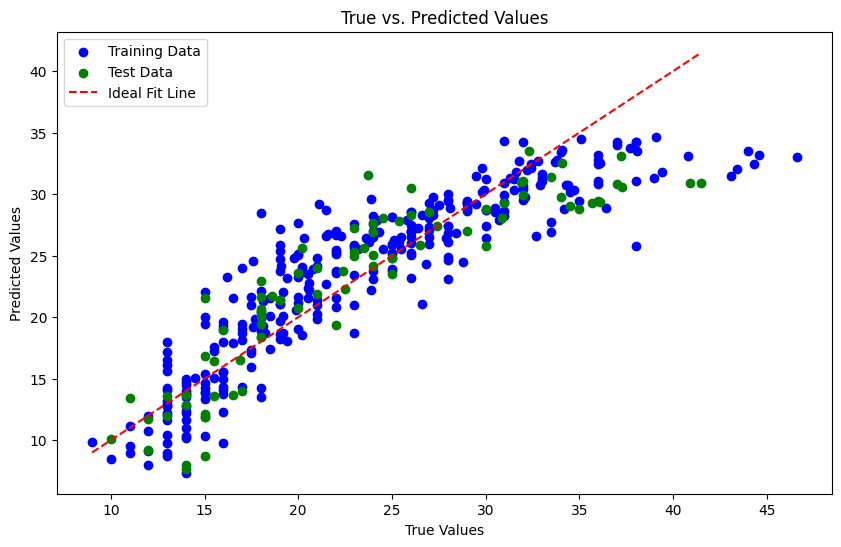

In [34]:
plt.figure(figsize=(10, 6))

# Training set
plt.scatter(y_train, train_pred, color='blue', label='Training Data')
# Test set
plt.scatter(y_test, test_pred, color='green', label='Test Data')

# Reference line (perfect prediction)
plt.plot([y_train.min(), y_test.max()], [y_train.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit Line')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values')
plt.legend()
plt.show()

#Scikit Implementation

In [35]:
# Create a Linear Regression model
regressor = LinearRegression()

# Train the model
regressor.fit(x_train_norm, y_train_norm)

LinearRegression()

## Testing the results

In [36]:
# standardize
x_test_norm = (x_test-mean_feat)/std_feat

# prediction on test data
test_pred_sci = regressor.predict(x_test_norm)
# reverse standardization
test_pred_sci *= std_label
test_pred_sci += mean_label

# prediction on train data
train_pred = linear_model.predict(x_train_norm)
# reverse standardization
train_pred *= std_label
train_pred += mean_label

# Convert test_pred to a NumPy array
# test_pred = test_pred.numpy()
# train_pred = train_pred.numpy()

In [37]:
mae = mean_absolute_error(y_test, test_pred_sci)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 2.71


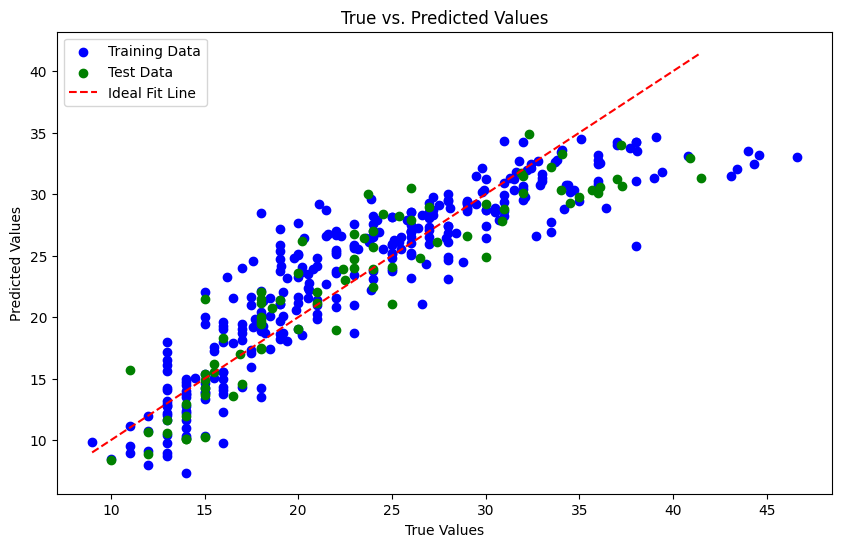

In [38]:
plt.figure(figsize=(10, 6))

# Training set
plt.scatter(y_train, train_pred, color='blue', label='Training Data')
# Test set
plt.scatter(y_test, test_pred_sci, color='green', label='Test Data')

# Reference line (perfect prediction)
plt.plot([y_train.min(), y_test.max()], [y_train.min(), y_test.max()], color='red', linestyle='--', label='Ideal Fit Line')

plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values')
plt.legend()
plt.show()

# Keras Implementation

In [46]:
Y[0]

18.0

In [54]:
# createmodel
model= Sequential()
model.add(Dense(1, input_dim=7, activation='relu'))
# youmayplay withdifferentnetworkarchitectures(addingnewlayers, and changingtheiramountof nodes)
# compilemodel
model.compile(loss='mean_squared_error', optimizer='adam', metrics= ['accuracy'])
# split the data
# X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size= 0.2, random_state= 0)
# fitthe model
model.fit(X_train, Y_train, epochs=100, verbose=0)
# evaluatethe model
mse_value, acc= model.evaluate(X_test, Y_test, verbose=0)
print('EvaluationMSE: '+str(mse_value))
# predictthe value
Y_pred= model.predict(X_test[0].reshape(1, -1))
print(Y_pred[0][0])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


EvaluationMSE: 605.1829833984375
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
0.0


In [51]:
# Define the model
model = keras.Sequential([
    Dense(1, input_shape=(x_train_norm.shape[1],))  # Output layer with 1 unit
])

# Compile the model
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train the model
model.fit(x_train_norm, y_train_norm, epochs=1000, verbose=0)

# Make predictions on the test set
y_pred_norm = model.predict(x_test_norm)

# Reverse the standardization to get actual predictions
y_pred = y_pred_norm.flatten() * std_label + mean_label  # Flatten the predictions

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [52]:
# standardize
x_test_norm = (x_test-mean_feat)/std_feat

# prediction on test data
test_pred_ker = model.predict(x_test_norm)
# reverse standardization
test_pred_ker *= std_label
test_pred_ker += mean_label

# prediction on train data
train_pred = linear_model.predict(x_train_norm)
# reverse standardization
train_pred *= std_label
train_pred += mean_label

# Convert test_pred to a NumPy array
# test_pred = test_pred.numpy()
# train_pred = train_pred.numpy()

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [53]:
mae = mean_absolute_error(y_test, test_pred_ker)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 2.71
